<a href="https://colab.research.google.com/github/Elsacred02/Progetto_AML_2025_2026/blob/ResNet50/Codice_progetto_AML_ResNet_2025_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

from google.colab import drive
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import image_dataset_from_directory

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# ResNet50 + preprocessing specifico
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

BATCH_SIZE = 32
IMG_SIZE = (224, 224)
SEED = 123


In [ ]:
# Monta Google Drive
from google.colab import drive
drive.mount('/content/drive')

# copia dataset in locale
source_dir = "/content/drive/MyDrive/Colab Notebooks/sea_animals"
local_dir = "/content/sea_animals_local"

if not os.path.exists(local_dir):
    print("Inizio copia dataset in locale...")
    shutil.copytree(source_dir, local_dir)
    print("Copia completata!")
else:
    print("Dataset già in locale.")

DATA_DIR = local_dir

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset già in locale.


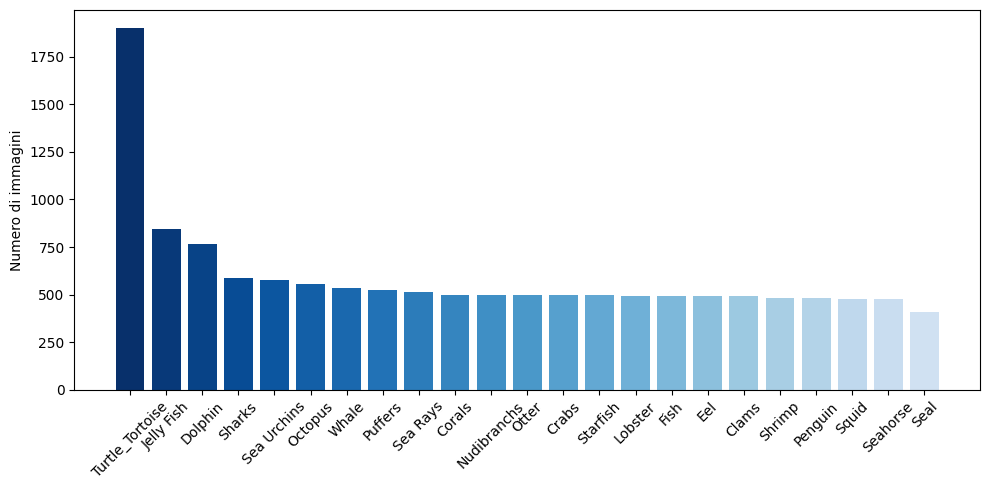

In [ ]:
# Controllo bilanciamento dataset

dict_targets_NElements = {}

for directory in os.listdir(DATA_DIR):
    dict_targets_NElements[directory] = len(os.listdir(os.path.join(DATA_DIR, directory)))

dict_targets_NElements = dict(sorted(dict_targets_NElements.items(), key=lambda x: x[1], reverse=True))

colors = plt.cm.Blues(np.linspace(1, 0.2, len(dict_targets_NElements)))

plt.figure(figsize=(10, 5))
plt.bar(dict_targets_NElements.keys(), dict_targets_NElements.values(), color=colors)
plt.xticks(rotation=45)
plt.ylabel("Numero di immagini")
plt.tight_layout()
plt.show()


In [ ]:
# Class weights (dataset sbilanciato)

num_classes = len(dict_targets_NElements)
print(f"Numero di classi: {num_classes}")

all_labels = []
class_names_ordered = sorted(dict_targets_NElements.keys())

for idx, class_name in enumerate(class_names_ordered):
    num_samples = dict_targets_NElements[class_name]
    all_labels.extend([idx] * num_samples)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=all_labels
)

class_weights = dict(enumerate(class_weights_array))

print("\nClass Weights calcolati:")
for class_idx, class_name in enumerate(class_names_ordered):
    print(f"  {class_name}: {class_weights[class_idx]:.4f}")


Numero di classi: 23

Class Weights calcolati:
  Clams: 1.2017
  Corals: 1.1849
  Crabs: 1.1873
  Dolphin: 0.7699
  Eel: 1.1969
  Fish: 1.1969
  Jelly Fish: 0.7005
  Lobster: 1.1945
  Nudibranchs: 1.1849
  Octopus: 1.0596
  Otter: 1.1873
  Penguin: 1.2292
  Puffers: 1.1241
  Sea Rays: 1.1526
  Sea Urchins: 1.0265
  Seahorse: 1.2395
  Seal: 1.4386
  Sharks: 1.0107
  Shrimp: 1.2267
  Squid: 1.2369
  Starfish: 1.1897
  Turtle_Tortoise: 0.3112
  Whale: 1.1072


In [ ]:
# Suddivisione dataset (train/val/test)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_test_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds = val_test_ds.take(val_test_batches // 2)
test_ds = val_test_ds.skip(val_test_batches // 2)

class_names = train_ds.class_names
print("Class names (ordine Keras):", class_names)


Found 13599 files belonging to 23 classes.
Using 10880 files for training.
Found 13599 files belonging to 23 classes.
Using 2719 files for validation.
Class names (ordine Keras): ['Clams', 'Corals', 'Crabs', 'Dolphin', 'Eel', 'Fish', 'Jelly Fish', 'Lobster', 'Nudibranchs', 'Octopus', 'Otter', 'Penguin', 'Puffers', 'Sea Rays', 'Sea Urchins', 'Seahorse', 'Seal', 'Sharks', 'Shrimp', 'Squid', 'Starfish', 'Turtle_Tortoise', 'Whale']


In [ ]:
# Preprocessing ResNet

train_ds_RN = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds_RN   = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds_RN  = test_ds.map(lambda x, y: (preprocess_input(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds_RN = train_ds_RN.shuffle(100).prefetch(buffer_size=AUTOTUNE)
val_ds_RN   = val_ds_RN.prefetch(buffer_size=AUTOTUNE)
test_ds_RN  = test_ds_RN.prefetch(buffer_size=AUTOTUNE)


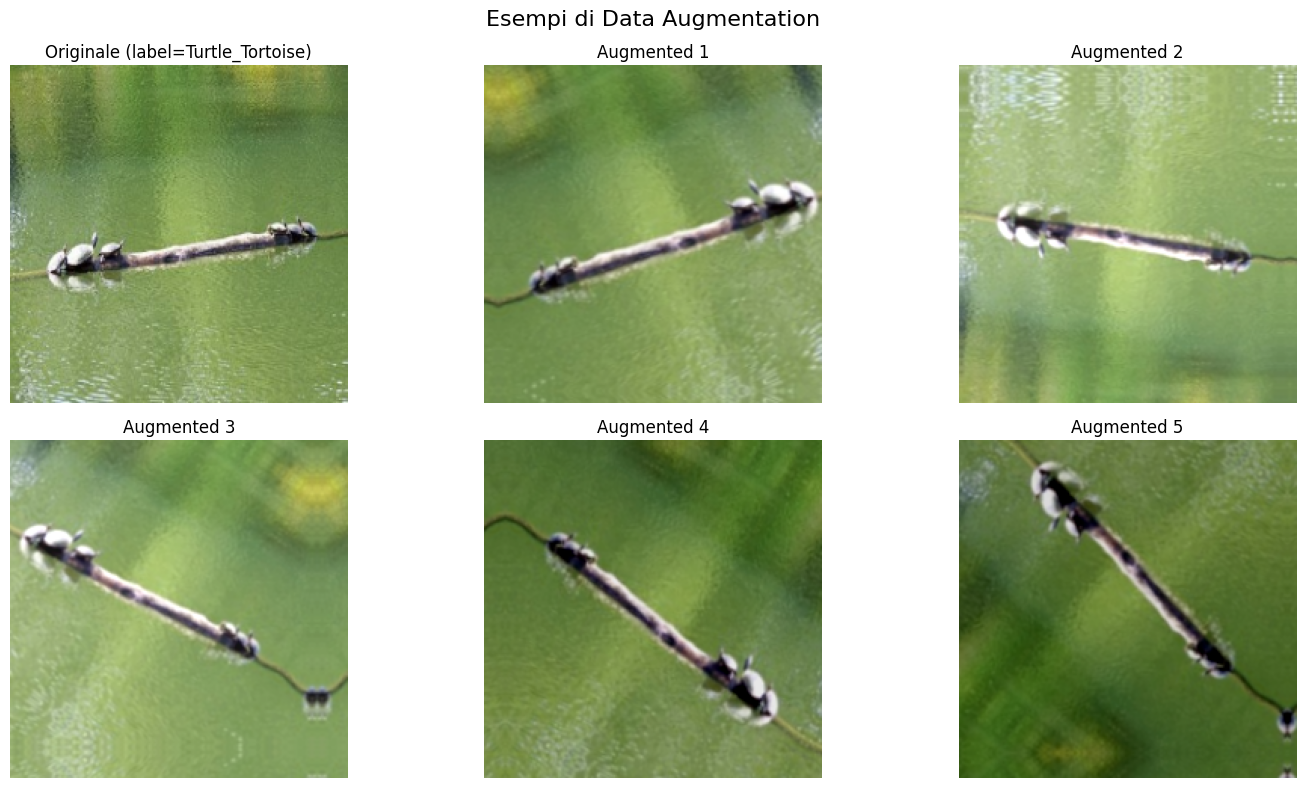

In [ ]:
# Data Augmentation + esempi

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomFlip("vertical"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.15),
    tf.keras.layers.RandomBrightness(0.15),
])

for images, labels in train_ds.take(1):
    batch_images = images
    batch_labels = labels

original_image = batch_images[0]
label = batch_labels[0]

original_image = tf.clip_by_value(original_image, 0, 255)
original_image = tf.cast(original_image, tf.uint8)
image_batch = tf.expand_dims(original_image, axis=0)

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(original_image)
plt.title(f"Originale (label={class_names[label]})")
plt.axis("off")

for i in range(1, 6):
    augmented = data_augmentation(image_batch, training=True)
    aug_img = tf.cast(tf.clip_by_value(augmented[0], 0, 255), tf.uint8)

    plt.subplot(2, 3, i + 1)
    plt.imshow(aug_img)
    plt.title(f"Augmented {i}")
    plt.axis("off")

plt.suptitle("Esempi di Data Augmentation", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
# Costruzione modello ResNet50 (Transfer Learning)

base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_model.trainable = False  # fase 1: backbone congelato

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)

outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="ResNet50_TransferLearning")
model.summary()


Model: "ResNet50_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        47,127 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,643,031 (90.19 MB)

 Trainable params: 51,223 (200.09 KB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:
# Training fase 1 (solo head)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping_phase1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_phase1 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history_1 = model.fit(
    train_ds_RN,
    validation_data=val_ds_RN,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping_phase1, reduce_lr_phase1]
)


Epoch 1/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 76s 161ms/step - accuracy: 0.2665 - loss: 3.0423 - val_accuracy: 0.6257 - val_loss: 1.3859 - learning_rate: 0.0010
Epoch 2/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 65s 170ms/step - accuracy: 0.4430 - loss: 2.1196 - val_accuracy: 0.6510 - val_loss: 1.3702 - learning_rate: 0.0010
Epoch 3/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 61s 159ms/step - accuracy: 0.4746 - loss: 2.0040 - val_accuracy: 0.6704 - val_loss: 1.2930 - learning_rate: 0.0010
Epoch 4/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 61s 158ms/step - accuracy: 0.4761 - loss: 1.9467 - val_accuracy: 0.6682 - val_loss: 1.3289 - learning_rate: 0.0010
Epoch 5/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 61s 159ms/step - accuracy: 0.4981 - loss: 1.8796 - val_accuracy: 0.6756 - val_loss: 1.2328 - learning_rate: 0.0010
Epoch 6/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 61s 159ms/step - accuracy: 0.5012 - loss: 1.8320 - val_accuracy: 0.6823 - val_loss: 1.2355 - learning_rate: 0.0010
Epoch 7/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.51

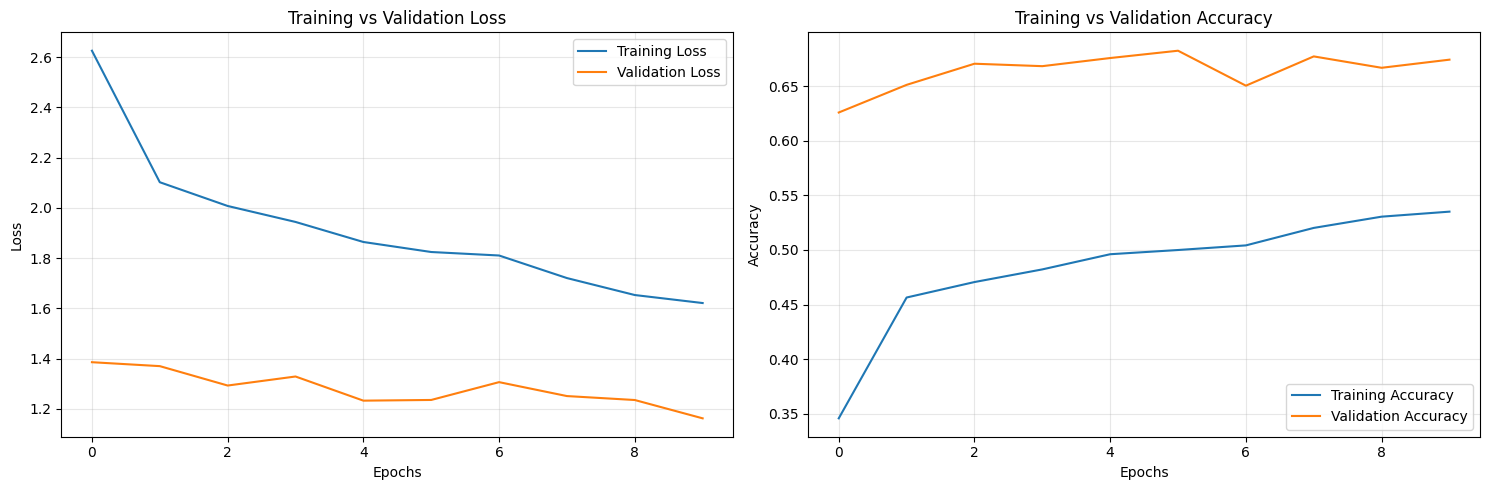

In [ ]:
# Stampo in un grafico l'evoluzione dell'accuratezza in training e validazione

history_dict = history_1.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_dict['loss'], label='Training Loss')
ax1.plot(history_dict['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_dict['accuracy'], label='Training Accuracy')
ax2.plot(history_dict['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Fine-tuning (sblocca ultimi 10 layer)

base_model.trainable = True

# Sblocca solo gli ultimi 10 layer del backbone
N = 10
for layer in base_model.layers[:-N]:
    layer.trainable = False

trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)
total_layers = len(base_model.layers)
print(f"Trainable layers (backbone): {trainable_layers} / {total_layers}")

model.summary()

Trainable layers (backbone): 10 / 175


Model: "ResNet50_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        47,127 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,745,479 (90.58 MB)

 Trainable params: 4,516,887 (17.23 MB)

 Non-trainable params: 19,126,144 (72.96 MB)

 Optimizer params: 102,448 (400.19 KB)

In [ ]:
# training fase 2

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping_phase2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_phase2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

history_2 = model.fit(
    train_ds_RN,
    validation_data=val_ds_RN,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stopping_phase2, reduce_lr_phase2]
)


Epoch 1/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 80s 182ms/step - accuracy: 0.5200 - loss: 1.6822 - val_accuracy: 0.6890 - val_loss: 1.1418 - learning_rate: 1.0000e-04
Epoch 2/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 67s 175ms/step - accuracy: 0.5366 - loss: 1.5712 - val_accuracy: 0.6957 - val_loss: 1.2137 - learning_rate: 1.0000e-04
Epoch 3/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.5730 - loss: 1.4636
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
340/340 ━━━━━━━━━━━━━━━━━━━━ 81s 174ms/step - accuracy: 0.5730 - loss: 1.4636 - val_accuracy: 0.6987 - val_loss: 1.1462 - learning_rate: 1.0000e-04
Epoch 4/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 67s 175ms/step - accuracy: 0.6043 - loss: 1.3458 - val_accuracy: 0.7031 - val_loss: 1.2029 - learning_rate: 5.0000e-05
Epoch 5/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 67s 175ms/step - accuracy: 0.6122 - loss: 1.2907 - val_accuracy: 0.7173 - val_loss: 1.0675 - learning_rate: 5.0000e-05
Epoch 6/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 67s 175ms/st

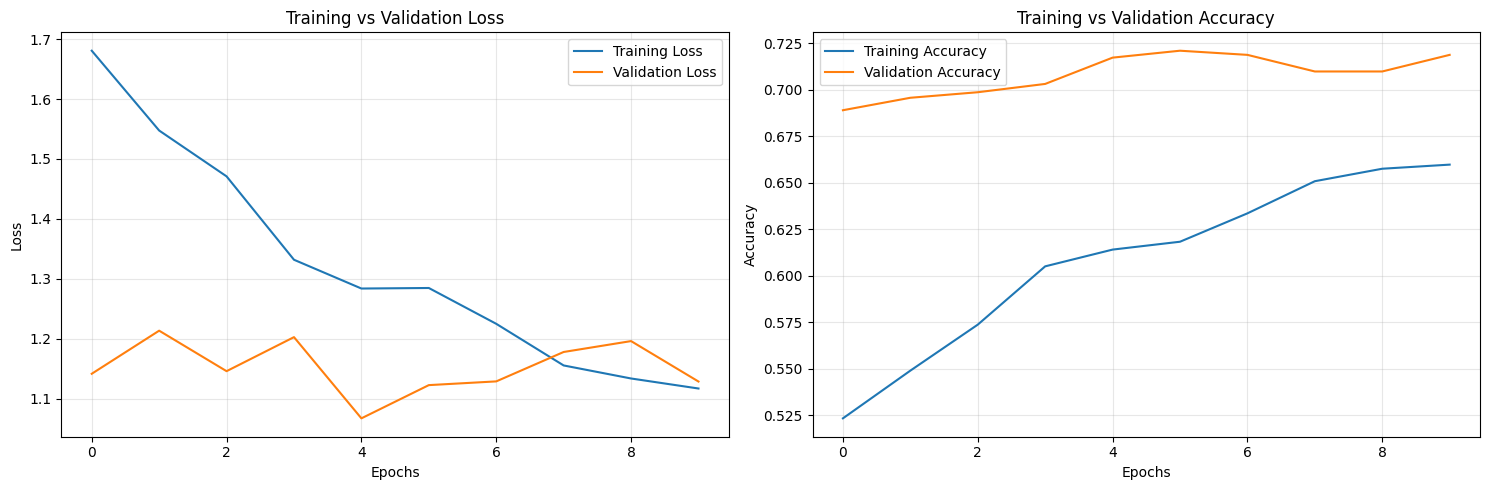

In [ ]:
# Stampo in un grafico l'evoluzione dell'accuratezza in training e validazione

history_dict = history_2.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_dict['loss'], label='Training Loss')
ax1.plot(history_dict['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_dict['accuracy'], label='Training Accuracy')
ax2.plot(history_dict['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

--- Valutazione sul Test Set (Phase 2) ---
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.7627 - loss: 1.0118

Test Loss: 0.9984
Test Accuracy: 0.7556

--- Classification Report (Phase 2) ---
                 precision    recall  f1-score   support

          Clams      0.639     0.511     0.568        45
         Corals      0.545     0.735     0.626        49
          Crabs      0.839     0.979     0.904        48
        Dolphin      0.624     0.902     0.738        92
            Eel      0.647     0.635     0.641        52
           Fish      0.694     0.481     0.568        52
     Jelly Fish      0.967     0.978     0.972        89
        Lobster      0.606     0.769     0.678        52
    Nudibranchs      0.875     0.538     0.667        52
        Octopus      0.528     0.528     0.528        53
          Otter      1.000     0.870     0.930        46
        Penguin      0.771     0.600     0.675        45
        Puffers      0.655     0.776     0.710        49
 

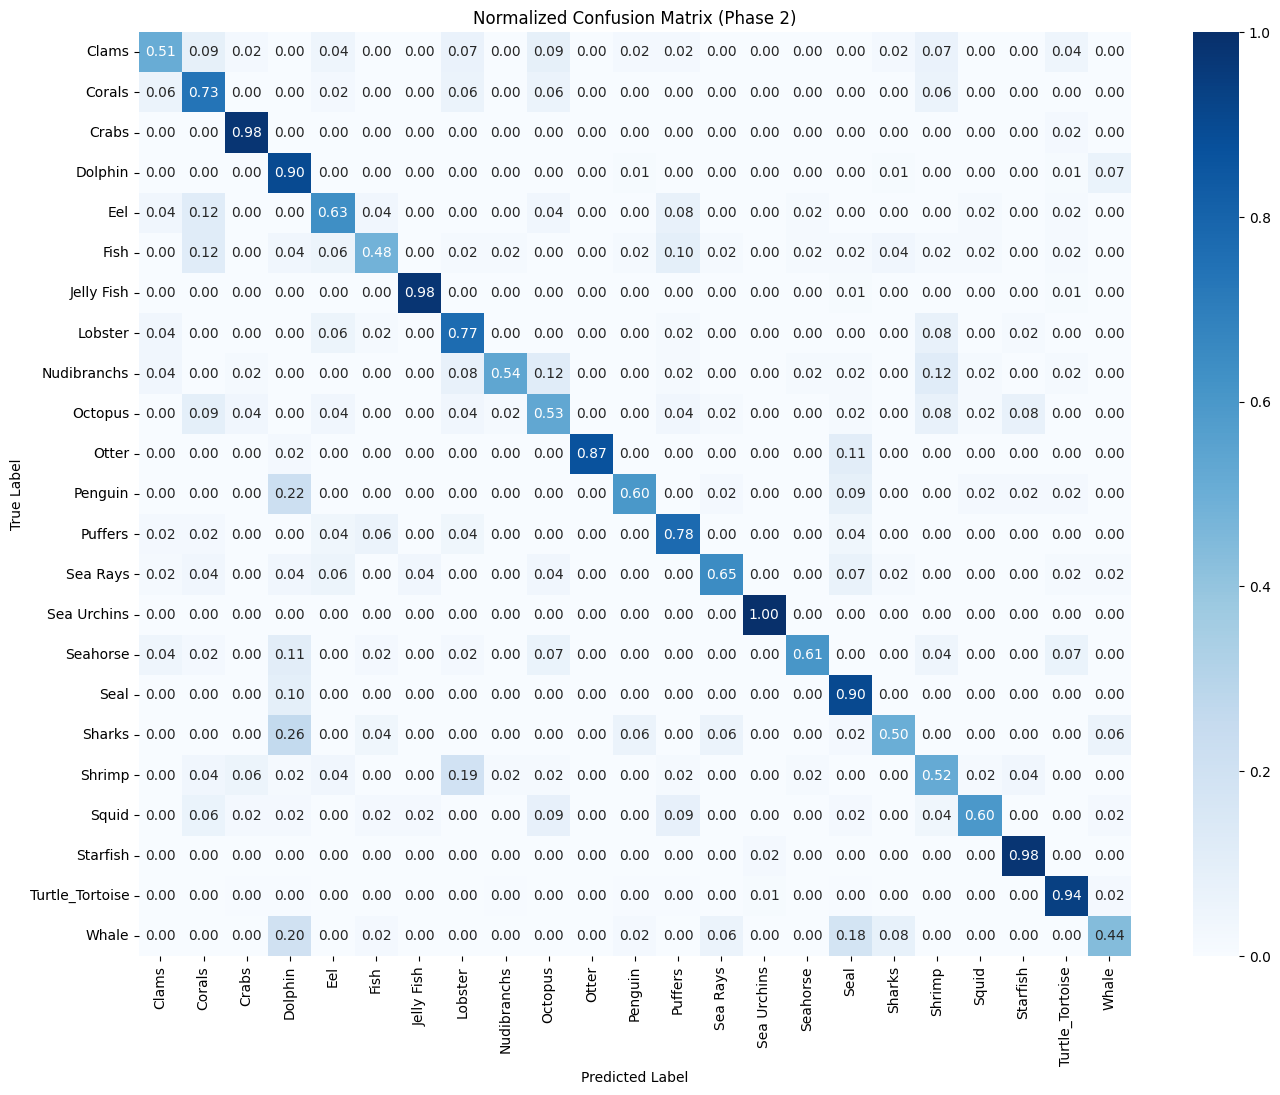

In [ ]:
# Valutazione + Confusion Matrix

print("--- Valutazione sul Test Set (Phase 2) ---")
test_loss, test_accuracy = model.evaluate(test_ds_RN, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}\n")

y_true = []
y_pred = []

for x_batch, y_batch in test_ds_RN:
    preds = model.predict(x_batch, verbose=0)
    y_pred.append(np.argmax(preds, axis=1))
    y_true.append(y_batch.numpy())

y_true = np.concatenate(y_true, axis=0)
y_pred = np.concatenate(y_pred, axis=0)

print("--- Classification Report (Phase 2) ---")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(16, 12))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (Phase 2)")
plt.show()
